In [1]:
! pip install kaggle
! pip install onnx
! pip install dagshub
! pip install mlflow
from google.colab import drive
drive.mount('/content/drive')
! mkdir ~/.kaggle
! cp /content/drive/MyDrive/ColabNotebooks/kaggle_API_credentials/kaggle.json ~/.kaggle/kaggle.json
! chmod 600 ~/.kaggle/kaggle.json
# ! kaggle competitions download -c walmart-recruiting-store-sales-forecasting
# ! unzip walmart-recruiting-store-sales-forecasting

Mounted at /content/drive


In [2]:
# ! unzip test.csv.zip
# ! unzip train.csv.zip
# ! unzip sampleSubmission.csv.zip
# ! unzip features.csv.zip

In [3]:
# ! rm -rf test.csv.zip
# ! rm -rf train.csv.zip
# ! rm -rf sampleSubmission.csv.zip
# ! rm -rf features.csv.zip

In [4]:
# 1. Clone your GitHub repo
!git clone https://github.com/arazm21/ML-final_project

# 2. Add the cloned repo (or specific folder) to sys.path
import sys
sys.path.insert(0, '/content/ML-final_project')


Cloning into 'ML-final_project'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 24 (delta 0), reused 21 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 3.72 MiB | 10.99 MiB/s, done.


In [1]:
import torch # Main PyTorch Library
from torch import nn # Used for creating the layers and loss function
from torch.optim import Adam # Adam Optimizer
import torchvision.transforms as transforms # Transform function used to modify and preprocess all the images
from torch.utils.data import Dataset, DataLoader # Dataset class and DataLoader for creating the objects
from sklearn.preprocessing import LabelEncoder # Label Encoder to encode the classes from strings to numbers
import matplotlib.pyplot as plt # Used for visualizing the images and plotting the training progress
from PIL import Image # Used to read the images from the directory
import pandas as pd # Used to read/create dataframes (csv) and process tabular data
import numpy as np # preprocessing and numerical/mathematical operations
import os # Used to read the images path from the directory

device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac
print("Device available: ", device)

Device available:  cpu


In [69]:
# features_df = pd.read_csv('ML-final_project/data/features.csv/features.csv')
# sample_submission_df = pd.read_csv('ML-final_project/data/sampleSubmission.csv/sampleSubmission.csv')
# test_df = pd.read_csv('ML-final_project/data/test.csv/test.csv')
# train_df = pd.read_csv('ML-final_project/data/train.csv/train.csv')
# stores_df = pd.read_csv('ML-final_project/data/stores.csv')

features_df = pd.read_csv('data/features.csv/features.csv')
sample_submission_df = pd.read_csv('data/sampleSubmission.csv/sampleSubmission.csv')
test_df = pd.read_csv('data/test.csv/test.csv')
train_df = pd.read_csv('data/train.csv/train.csv')
stores_df = pd.read_csv('data/stores.csv')

In [4]:
display(train_df.head())

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [70]:
import pandas as pd

# Use the actual date range present in the data
all_dates = sorted(train_df['Date'].unique())

# Collect filled groups
filled_groups = []

# Process each Store/Dept group
for (store, dept), group in train_df.groupby(['Store', 'Dept']):
    group = group.set_index('Date')

    # Reindex to actual full dates in data
    reindexed = group.reindex(all_dates)
    reindexed.index.name = 'Date'

    # Fill identifying columns
    reindexed['Store'] = store
    reindexed['Dept'] = dept

    # Fill missing sales with 0
    reindexed['Weekly_Sales'] = reindexed['Weekly_Sales'].fillna(0)

    filled_groups.append(reindexed.reset_index())

# Concatenate full DataFrame
train_df_filled = pd.concat(filled_groups).sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)


In [67]:
train_df_filled.to_csv('temp/train_df_filled.csv', index=False)

In [71]:
train_df_filled = train_df_filled.drop(columns=['IsHoliday'], errors='ignore')

# Merge on 'Store' and 'Date'
train_merged = pd.merge(train_df_filled, features_df, on=['Store', 'Date'], how='left')
test_merged = pd.merge(test_df, features_df, on=['Store', 'Date'], how='left')
train_merged = pd.merge(train_merged, stores_df, on='Store', how='left')
test_merged = pd.merge(test_merged, stores_df, on='Store', how='left')

In [72]:
print(train_merged.columns)
print(train_merged.dtypes)
display(train_merged.head())


Index(['Date', 'Store', 'Dept', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'IsHoliday', 'Type', 'Size'],
      dtype='object')
Date             object
Store             int64
Dept              int64
Weekly_Sales    float64
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
Type             object
Size              int64
dtype: object


,Date,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size
0,2010-02-05,1,1,24924.50,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,2010-02-12,1,1,46039.49,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,2010-02-19,1,1,41595.55,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,2010-02-26,1,1,19403.54,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,2010-03-05,1,1,21827.90,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


## helper functions

### 1.feature engineering functions

In [ ]:
def add_holiday_lookahead(df):
    """
    Adds:
    - IsHolidayNextWeek: True if this week OR next week is a holiday.
    - IsHolidayIn2Weeks: True if this week OR next 2 weeks are holidays.
    """
    df = df.sort_values(by=['Store', 'Date']).copy()

    # current and future IsHoliday flags
    curr = df['IsHoliday'].astype(bool)
    next_1 = df.groupby('Store')['IsHoliday'].shift(-1).fillna(False).astype(bool)
    next_2 = df.groupby('Store')['IsHoliday'].shift(-2).fillna(False).astype(bool)

    df['IsHolidayNextWeek'] = (curr | next_1).astype(int)
    df['IsHolidayIn2Weeks'] = (curr | next_1 | next_2).astype(int)

    return df

def add_date_features(df):
    df['Date'] = pd.to_datetime(df['Date'])
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week
    # df['Day'] = df['Date'].dt.day
    # df['DayOfWeek'] = df['Date'].dt.weekday  # Monday=0, Sunday=6
    return df

# use this method for model which are not sequencial, i.e.xgboost
def drop_unneeded_columns(df, drop_date=True):
    """
    Drop or convert fields not usable by XGBoost directly.
    """
    df = df.copy()
    if drop_date and 'Date' in df.columns:
        df = df.drop(columns=['Date'])
    return df


## connecting wandb and dagshub

In [17]:
project_name = 'ML-final_project'
run_name = "test_run_1"
repo_owner = "arazm21"

In [18]:
import wandb
wandb.login()

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: arazm21 (arazm21-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [19]:
import dagshub
import mlflow
import mlflow.sklearn
dagshub.init(repo_owner=repo_owner, repo_name=project_name, mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=cd25537e-680f-44a0-9c17-2795377d273b&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=6081d3ccba1aaba46d9c80c9162f53fae7ff11afa8bf92adafb899c73f4b1b7a




Output()

Accessing as arazm21

Initialized MLflow to track repo "arazm21/ML-final_project"

Repository arazm21/ML-final_project initialized!

In [ ]:
# with wandb.init(project=project_name,
#                 config=hyperparameters,
#                 name = run_name):


## getting data ready

3


,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday,Type,Size
0,1,1,2010-02-05,24924.50,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


## plots

### checking 3 departament/store combinations

143 2010-02-05 00:00:00 2012-10-26 00:00:00
143 2010-02-05 00:00:00 2012-10-26 00:00:00
143 2010-02-05 00:00:00 2012-10-26 00:00:00


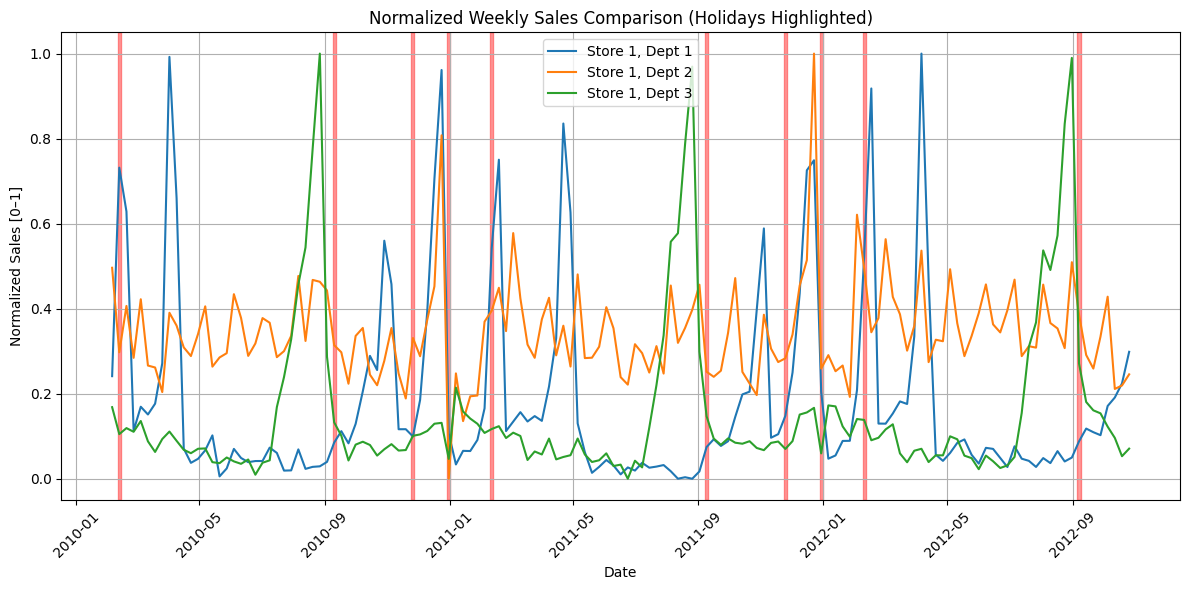

In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
train_merged = train_merged.sort_values(['Store', 'Dept', 'Date'])

groups = [g for _, g in train_df.groupby(['Store', 'Dept']) if len(g) > 100]
selected = groups[:3]

selected_series = []
for (store, dept), group in train_merged.groupby(['Store', 'Dept']):
    if len(group) >= 100:
        selected_series.append((store, dept))
        if len(selected_series) == 3:
            break

# Plot normalized series
plt.figure(figsize=(12, 6))
ax = plt.gca()

for i, (store, dept) in enumerate(selected_series):
    series = train_merged[(train_merged['Store'] == store) & 
                          (train_merged['Dept'] == dept)].sort_values('Date').copy()

    series['Date'] = pd.to_datetime(series['Date'])  # 🛠️ Ensure datetime
    print(len(series), series["Date"].iloc[0], series["Date"].iloc[-1])

    # Min-Max normalization
    normalized_sales = (series['Weekly_Sales'] - series['Weekly_Sales'].min()) / \
                       (series['Weekly_Sales'].max() - series['Weekly_Sales'].min())
    
    plt.plot(series['Date'], normalized_sales, label=f"Store {store}, Dept {dept}")

    # Highlight holiday weeks
    holidays = series[series['IsHoliday'] == True]['Date']
    for holiday_date in holidays:
        ax.axvspan(holiday_date - pd.Timedelta(days=1.5),
                   holiday_date + pd.Timedelta(days=1.5),
                   color='red', alpha=0.15)

plt.title('Normalized Weekly Sales Comparison (Holidays Highlighted)')
plt.xlabel('Date')
plt.ylabel('Normalized Sales [0–1]')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [39]:
# Expected sales range differences:
print(train_merged.groupby(['Store','Dept'])['Weekly_Sales'].agg([np.mean, np.std]))

                    mean           std
Store Dept                            
1     1     22513.322937   9854.349032
      2     46102.090420   3440.673222
      3     13150.478042   8708.978853
      4     36964.154476   2930.698313
      5     24257.941119  11330.286495
...                  ...           ...
45    94     3690.272090   1852.287364
      95    52896.166643   5117.961708
      96        2.970000      0.042426
      97     6466.961888    659.739542
      98      561.239037    371.286705

[3331 rows x 2 columns]


C:\Users\alex\AppData\Local\Temp\ipykernel_32772\3343407106.py:2: FutureWarning: The provided callable <function mean at 0x0000021C642AF420> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  print(train_merged.groupby(['Store','Dept'])['Weekly_Sales'].agg([np.mean, np.std]))
C:\Users\alex\AppData\Local\Temp\ipykernel_32772\3343407106.py:2: FutureWarning: The provided callable <function std at 0x0000021C642AF560> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  print(train_merged.groupby(['Store','Dept'])['Weekly_Sales'].agg([np.mean, np.std]))


### trends across all stores/departaments

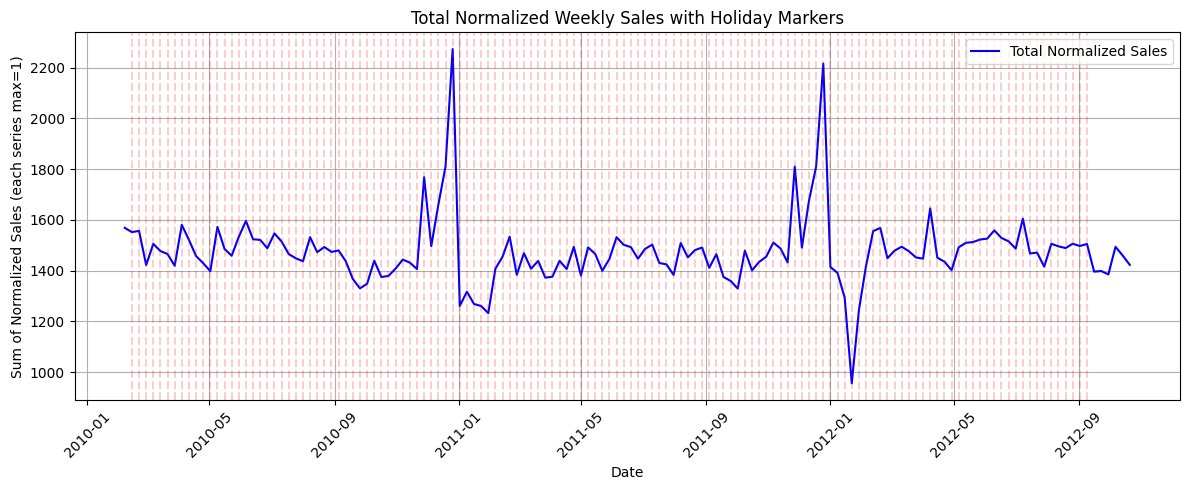

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure Date is datetime
train_merged['Date'] = pd.to_datetime(train_merged['Date'])

# Define common weekly index
common_index = pd.date_range(start=train_merged['Date'].min(),
                             end=train_merged['Date'].max(),
                             freq='W')

# Step 1: Normalize each Store–Dept combo (max = 1)
normalized_series_list = []

for (store, dept), group in train_merged.groupby(['Store', 'Dept']):
    group = group.set_index('Date').sort_index()
    weekly_sales = group['Weekly_Sales'].resample('W').sum()

    max_sales = weekly_sales.max()
    if pd.isna(max_sales) or max_sales == 0:
        continue

    normalized = weekly_sales / max_sales
    normalized = normalized.reindex(common_index).interpolate(limit_direction='both')
    normalized_series_list.append(normalized)

# Step 2: Add all normalized series together
normalized_df = pd.DataFrame(normalized_series_list).T
total_normalized_sales = normalized_df.sum(axis=1)

# Step 3: Get unique holiday weeks (from any store/dept)
holiday_weeks = (
    train_merged[train_merged['IsHoliday'] == True]
    .set_index('Date')
    .resample('W').max()
    .index
)

# Step 4: Plot with holiday lines
plt.figure(figsize=(12, 5))
plt.plot(common_index, total_normalized_sales, color='blue', label='Total Normalized Sales')

# Draw vertical lines for holidays
for date in holiday_weeks:
    plt.axvline(date, color='red', linestyle='--', alpha=0.2)

plt.title('Total Normalized Weekly Sales with Holiday Markers')
plt.xlabel('Date')
plt.ylabel('Sum of Normalized Sales (each series max=1)')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### each store agains each other (summing departaments)

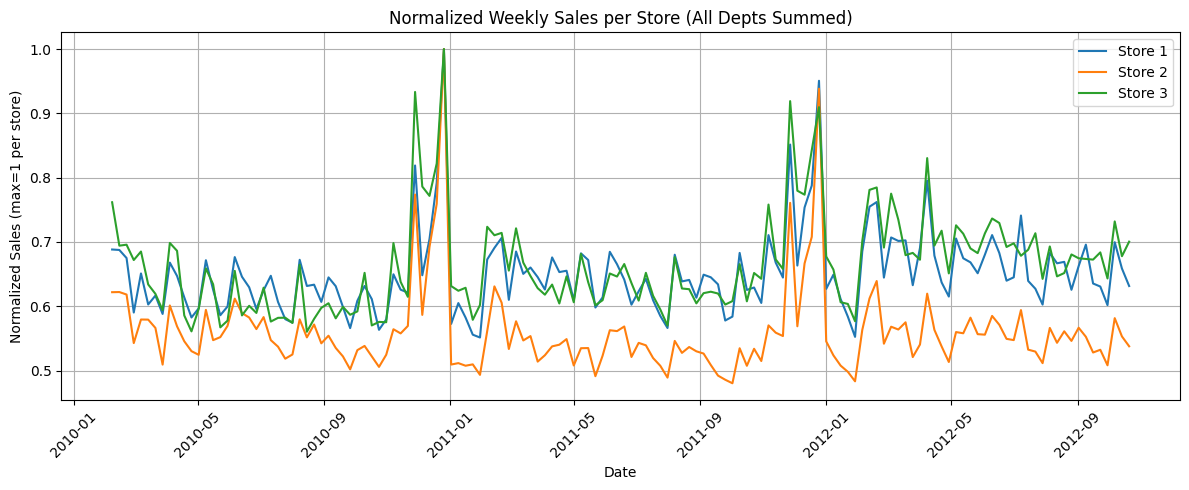

In [49]:
import matplotlib.pyplot as plt

# Set weekly index range
weekly_index = pd.date_range(train_merged['Date'].min(), train_merged['Date'].max(), freq='W')

# Step 1: Group by Store (sum over Depts)
store_series_list = []
store_ids = []

for store, group in train_merged.groupby('Store'):
    group = group.set_index('Date').sort_index()
    weekly_sales = group['Weekly_Sales'].resample('W').sum()

    max_sales = weekly_sales.max()
    if pd.isna(max_sales) or max_sales == 0:
        continue

    normalized = weekly_sales / max_sales
    normalized = normalized.reindex(weekly_index).interpolate(limit_direction='both')
    
    store_series_list.append(normalized)
    store_ids.append(store)

    if len(store_series_list) == 3:
        break

# Plot 3 stores
plt.figure(figsize=(12, 5))
for series, store_id in zip(store_series_list, store_ids):
    plt.plot(weekly_index, series, label=f"Store {store_id}")

plt.title("Normalized Weekly Sales per Store (All Depts Summed)")
plt.xlabel("Date")
plt.ylabel("Normalized Sales (max=1 per store)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### each departament agains each other (summing all stores)

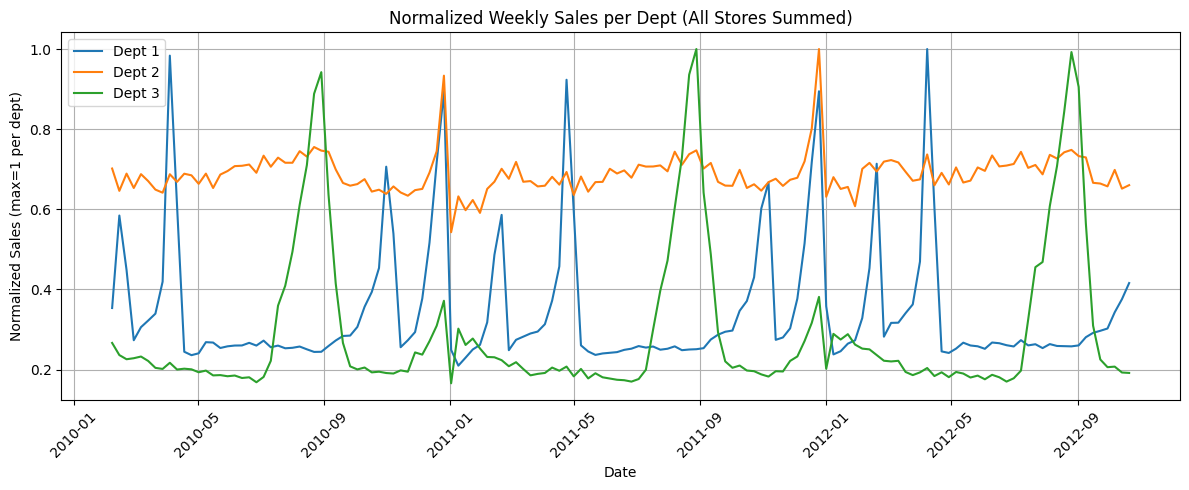

In [50]:
# Step 2: Group by Dept (sum over Stores)
dept_series_list = []
dept_ids = []

for dept, group in train_merged.groupby('Dept'):
    group = group.set_index('Date').sort_index()
    weekly_sales = group['Weekly_Sales'].resample('W').sum()

    max_sales = weekly_sales.max()
    if pd.isna(max_sales) or max_sales == 0:
        continue

    normalized = weekly_sales / max_sales
    normalized = normalized.reindex(weekly_index).interpolate(limit_direction='both')
    
    dept_series_list.append(normalized)
    dept_ids.append(dept)

    if len(dept_series_list) == 3:
        break

# Plot 3 depts
plt.figure(figsize=(12, 5))
for series, dept_id in zip(dept_series_list, dept_ids):
    plt.plot(weekly_index, series, label=f"Dept {dept_id}")

plt.title("Normalized Weekly Sales per Dept (All Stores Summed)")
plt.xlabel("Date")
plt.ylabel("Normalized Sales (max=1 per dept)")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## train!!!

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from fbprophet import Prophet

from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')
plt.style.use('fivethirtyeight')

def mean_absolute_percentage_error(y_true, y_pred): 
    """Calculates MAPE given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

ModuleNotFoundError: No module named 'seaborn'